In [ ]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
df = pd.read_csv("global_green_energy_pulse_20260112.csv")

print("Kích thước dữ liệu:", df.shape)

df.head()

Kích thước dữ liệu: (1920, 7)


,city,time,shortwave_radiation,wind_speed_100m,green_score,latitude,longitude
0,New York,2026-01-05 00:00:00,0.0,22.9,0.763333,40.71,-74.0
1,New York,2026-01-05 01:00:00,0.0,23.4,0.780000,40.71,-74.0
2,New York,2026-01-05 02:00:00,0.0,28.2,0.940000,40.71,-74.0
3,New York,2026-01-05 03:00:00,0.0,30.0,1.000000,40.71,-74.0
4,New York,2026-01-05 04:00:00,0.0,29.7,0.990000,40.71,-74.0


In [ ]:
print("Thông tin dataset:\n")
print(df.info())

print("\nSố giá trị thiếu:")
print(df.isna().sum())

Thông tin dataset:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1920 entries, 0 to 1919
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   city                 1920 non-null   object 
 1   time                 1920 non-null   object 
 2   shortwave_radiation  1920 non-null   float64
 3   wind_speed_100m      1920 non-null   float64
 4   green_score          1920 non-null   float64
 5   latitude             1920 non-null   float64
 6   longitude            1920 non-null   float64
dtypes: float64(5), object(2)
memory usage: 105.1+ KB
None

Số giá trị thiếu:
city                   0
time                   0
shortwave_radiation    0
wind_speed_100m        0
green_score            0
latitude               0
longitude              0
dtype: int64


In [ ]:
df = df.dropna(subset=[
    'shortwave_radiation',
    'wind_speed_100m'
])

print("Số dòng sau khi làm sạch:", len(df))

Số dòng sau khi làm sạch: 1920


In [ ]:
df['solar_level'] = pd.cut(
    df['shortwave_radiation'],
    bins=3,
    labels=["Low Solar", "Medium Solar", "High Solar"]
)

df['wind_level'] = pd.cut(
    df['wind_speed_100m'],
    bins=3,
    labels=["Low Wind", "Medium Wind", "High Wind"]
)

print("Đã tạo hai biến phân loại:")
print("solar_level và wind_level\n")

df[['shortwave_radiation','solar_level','wind_speed_100m','wind_level']].head()

Đã tạo hai biến phân loại:
solar_level và wind_level



,shortwave_radiation,solar_level,wind_speed_100m,wind_level
0,0.0,Low Solar,22.9,Low Wind
1,0.0,Low Solar,23.4,Low Wind
2,0.0,Low Solar,28.2,Medium Wind
3,0.0,Low Solar,30.0,Medium Wind
4,0.0,Low Solar,29.7,Medium Wind


In [ ]:
print("====================================================")
print("BÁO CÁO PHÂN TÍCH CHI-SQUARE")
print("====================================================")
print("1. Giới thiệu nghiên cứu")
print("Trong phân tích này, chúng tôi sử dụng tập dữ liệu Global Green Energy Pulse.")
print("Mục tiêu của phân tích là kiểm tra xem mức độ bức xạ mặt trời (solar_level) và mức độ tốc độ gió (wind_level)")
print("có mối liên hệ thống kê với nhau hay không.")
print("Hai biến được nghiên cứu:")
print("- solar_level: mức bức xạ mặt trời (Low, Medium, High)")
print("- wind_level: mức tốc độ gió (Low, Medium, High)\n")

print("2. Các giả thuyết kiểm định")

print("H0: solar_level và wind_level độc lập với nhau.")
print("Ha: solar_level và wind_level có mối liên hệ với nhau.\n")


print("3. Bảng tần số quan sát (Observed Frequency Table)")

contingency_table = pd.crosstab(df['solar_level'], df['wind_level'])

print(contingency_table)
print("\n")
print("4. Kết quả tính toán thống kê Chi-square")

chi2, p, dof, expected = stats.chi2_contingency(contingency_table)

print("Chi-square value:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)
print("\n")

print("5. Bảng giá trị kỳ vọng (Expected Frequency Table)")

expected_table = pd.DataFrame(
    expected,
    index=contingency_table.index,
    columns=contingency_table.columns
)
print(expected_table)
print("\n")

print("6. Giải thích kết quả")

alpha = 0.05

if p < alpha:
    print("Vì p-value <", alpha, " nên chúng ta bác bỏ giả thuyết H0.")
    print("Điều này cho thấy có bằng chứng thống kê rằng, mức bức xạ mặt trời và tốc độ gió có mối liên hệ với nhau.")
else:
    print("Vì p-value >=", alpha, " nên chúng ta không đủ bằng chứng để bác bỏ H0.")
    print("Điều này cho thấy hai biến có thể độc lập với nhau.")

BÁO CÁO PHÂN TÍCH CHI-SQUARE
1. Giới thiệu nghiên cứu
Trong phân tích này, chúng tôi sử dụng tập dữ liệu Global Green Energy Pulse.
Mục tiêu của phân tích là kiểm tra xem mức độ bức xạ mặt trời (solar_level) và mức độ tốc độ gió (wind_level)
có mối liên hệ thống kê với nhau hay không.
Hai biến được nghiên cứu:
- solar_level: mức bức xạ mặt trời (Low, Medium, High)
- wind_level: mức tốc độ gió (Low, Medium, High)

2. Các giả thuyết kiểm định
H0: solar_level và wind_level độc lập với nhau.
Ha: solar_level và wind_level có mối liên hệ với nhau.

3. Bảng tần số quan sát (Observed Frequency Table)
wind_level    Low Wind  Medium Wind  High Wind
solar_level                                   
Low Solar         1001          482         72
Medium Solar       185           85          3
High Solar          67           25          0


4. Kết quả tính toán thống kê Chi-square
Chi-square value: 12.866497262386863
p-value: 0.011946873861610918
Degrees of freedom: 4


5. Bảng giá trị kỳ vọng (Expect

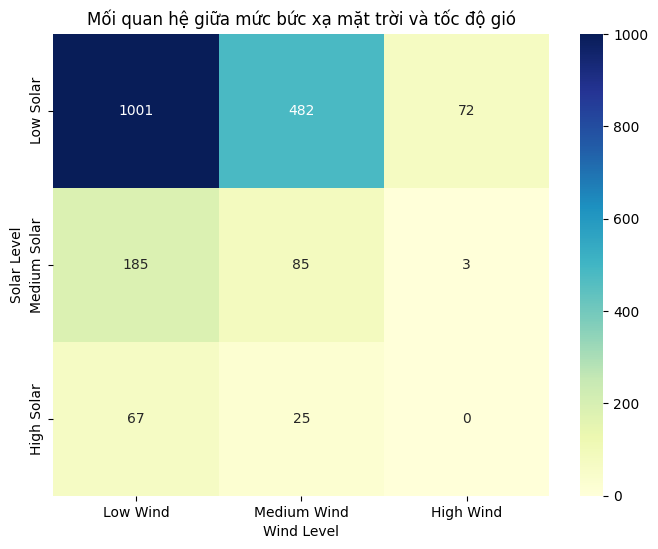

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    contingency_table,
    annot=True,
    cmap="YlGnBu",
    fmt="d"
)

plt.title("Mối quan hệ giữa mức bức xạ mặt trời và tốc độ gió")
plt.xlabel("Wind Level")
plt.ylabel("Solar Level")

plt.show()